In [1]:
print("Hello")

Hello


In [15]:
import requests

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages

from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from dotenv import load_dotenv

load_dotenv()

llm = ChatOpenAI()

class FinanceState(TypedDict):
    messages : Annotated[list[BaseMessage], add_messages]

@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = (
        "https://www.alphavantage.co/query"
        f"?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    )
    r = requests.get(url)
    return r.json()

tools = [get_stock_price]

llm_with_tools = llm.bind_tools(tools)

tool_node = ToolNode(tools)

graph = StateGraph(FinanceState)

def chat_node(state: FinanceState) : 
    messages = state["messages"]
    response = llm_with_tools.invoke(messages)
    
    return {
        "messages" : [response]
    }

graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")
# graph.add_edge("chat_node", END)
workflow = graph.compile()



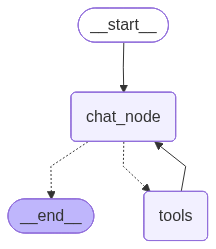

In [16]:
workflow

In [8]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}

workflow.invoke(initial_state)

{'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='50b6ae03-43ff-4a77-b353-b6b19a57677d'),
  AIMessage(content='The capital of India is New Delhi.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 13, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-CpziSJpKdZ5KFyJwZxT7jCF5AByEj', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019b4c14-ece3-7480-8c74-afb962c0182f-0', usage_metadata={'input_tokens': 13, 'output_tokens': 8, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 

In [3]:
import yfinance as yf

tm = yf.Ticker("TATAMOTORS.NS")
data = tm.history(period="1y")


$TATAMOTORS.NS: possibly delisted; no price data found  (period=1y) (Yahoo error = "No data found, symbol may be delisted")


In [ ]:
import yfinance as yf

data = yf.download(
    "TATAMOTORS.NS",
    start="2024-01-01",
    end="2025-01-01",
    progress=False,
    auto_adjust=False
)

print(data.head())


$TATAMOTORS.NS: possibly delisted; no price data found  (period=1mo) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['TATAMOTORS.NS']: possibly delisted; no price data found  (period=1mo) (Yahoo error = "No data found, symbol may be delisted")


Empty DataFrame
Columns: [(Adj Close, TATAMOTORS.NS), (Close, TATAMOTORS.NS), (High, TATAMOTORS.NS), (Low, TATAMOTORS.NS), (Open, TATAMOTORS.NS), (Volume, TATAMOTORS.NS)]
Index: []


In [13]:
import yfinance as yf

print(
    yf.download("RELIANCE.NS", period="1mo", progress=False).head()
)


Price             Close         High          Low         Open      Volume
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS
Date                                                                      
2025-11-26  1569.900024  1571.599976  1540.500000  1542.300049    14054299
2025-11-27  1563.400024  1575.500000  1556.000000  1575.000000     9794643
2025-11-28  1567.500000  1581.300049  1563.000000  1568.000000     8959508
2025-12-01  1566.099976  1577.500000  1563.599976  1575.000000     8920233
2025-12-02  1546.300049  1567.500000  1542.000000  1561.099976    11389150


In [12]:
import yfinance as yf

data = yf.download(
    "TATAMOTORS.NSE",
    period="1mo",
    progress=False
)

print(data.head())


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: TATAMOTORS.NSE"}}}
$TATAMOTORS.NSE: possibly delisted; no price data found  (period=1mo) (Yahoo error = "No data found, symbol may be delisted")

1 Failed download:
['TATAMOTORS.NSE']: possibly delisted; no price data found  (period=1mo) (Yahoo error = "No data found, symbol may be delisted")


Empty DataFrame
Columns: [(Adj Close, TATAMOTORS.NSE), (Close, TATAMOTORS.NSE), (High, TATAMOTORS.NSE), (Low, TATAMOTORS.NSE), (Open, TATAMOTORS.NSE), (Volume, TATAMOTORS.NSE)]
Index: []


In [1]:
from data_ingestion.fetch_articles import fetch_company_news

In [2]:
company = "Tesla"
api_key = "b72169cf3f794192928acbd7d79780c1"

In [3]:
articles = fetch_company_news(company, api_key)

In [5]:
for article in articles:
    # print(article['title'])
    # print(article['url'])
    print(article["content"])

<ul><li></li><li></li><li></li></ul>
Rivians AI pivot is about more than chasing Tesla
The EV maker was known for its outdoor-themed off-roaders. Why is it now chasing Elon Musk down an AI rabbit h… [+14013 chars]
Tesla drivers will soon be able to turn to Grok for directions; whether that’s a wrong turn remains to be seen.
The EV maker announced its 2025 Holiday update today on Elon Musk’s X, highlighting se… [+2509 chars]
Elon Musk confirmed this weekend that Tesla is testing its robotaxis in Austin without safety drivers on board, and his fanboys are losing their minds over it. Theres just one small problem: these te… [+2324 chars]
<ul><li></li><li></li><li></li></ul>
Eyes on the road, people.
Eyes on the road, people.
by
Andrew J. HawkinsClose
Andrew J. Hawkins
Posts from this author will be added to your daily email dig… [+4801 chars]
<ul><li></li><li></li><li></li></ul>
Automakers would be required to restrict their Level 2 driving system to safe road environments. That could ser

In [1]:
from evaluation.deepeval_test import run_deepeval


Loading PDF document... <class 'langchain_community.vectorstores.faiss.FAISS'>


In [2]:
question = "What risks did Tata Motors management mention?"

In [2]:
question = "News around Tata that is affecting its stock price?"

In [ ]:
run_deepeval(question)

c:\Users\mdaft\Desktop\CampusX\financial_bot_02\myenv\Lib\site-packages\rich\live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')